# Tutorial 2: Importing and Using FMUs for Co-Simulation

## Overview

In this tutorial we will explore how to import models defined in `Modelica` as Functional Mock-up Units (FMUs) for co-simulation using the `SystemSimulation` library. We will demonstrate how to set up a simple pendulum model, configure its parameters, run a simulation, and visualize the results.

We refer to the `Modelica`documentation for more details on creating FMUs:
- [Modelica - The Language](https://modelica.org/)
- [Modelica Association - Functional Mock-up Interface (FMI)](https://fmi-standard.org/)
- [Modelica by Example](https://mbe.modelica.university/)


## Learning Goals
- How to use `OMPython` to import FMUs for co-simulation from `Modelica` models.
- How to instantiate a `Modelica` model as a `FMUComponent` within the `syssimx` framework.
- How to set parameters, initialize, and run simulations on FMU components.
- Explore which functionality is available for FMU components in `syssimx`.

## Prequisites and Setup

In order to follow this tutorial we require the `OpenModelica` module `OMPython`. This is required to instantiate `ModelicaSystems` defined in `.mo` files as Python objects.

We refer to the [OMPython documentation](https://openmodelica.org/doc/OpenModelicaUsersGuide/latest/ompython.html) for more details on installation and setup.

Further we require the installation of the `FMPy' library to work with FMUs. Please refer to the [FMPy documentation](https://fmpy.readthedocs.io/en/latest/install/) for installation instructions.

In [36]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from fmpy import read_model_description, extract
from fmpy.fmi2 import FMU2Slave


## Step 1: Modelica Pendulum Model

The `Modelica`code below defines a simple pendulum model.
A major advantage of using `Modelica` for the definition of physical systems is the possibility to define equations in an acausal way.

This means that we do not have to define which variables are inputs and which are outputs.
The causality is determined during the compilation of the model.

When we export the model as an FMU for co-simulation, the causality is fixed and the inputs and outputs are defined.
The FMU contains a `modelDescription.xml` file that defines the model in detail. This information is used by the `FMUComponent` to interact with the model during simulation.


```Modelica
model Pendulum  
  // Imports
  import Modelica.Constants.pi;

  // Parameters
  parameter Real m(unit="kg") = 40;
  parameter Real L(unit="m") = 0.6;
  parameter Real q0(unit="rad") = 0;
  parameter Real omega0(unit="rad/s") = 0;
  parameter Real g(unit="m/s2") = 9.81;
  parameter Real inertia(unit="kg.m2") = 20;
  // Input torque at the pivot
  Modelica.Blocks.Interfaces.RealInput torque(unit="N.m");

  // Outputs
  Modelica.Blocks.Interfaces.RealOutput q(unit="rad");
  Modelica.Blocks.Interfaces.RealOutput omega(unit="rad/s");
  Modelica.Blocks.Interfaces.RealOutput alpha(unit="rad/s2") = der(omega);

initial equation
  q = q0;
  omega = omega0;

equation
  der(q)    = omega;
  der(omega) = -(m * g * L / inertia) * sin(q) + torque / inertia;
end Pendulum;

## Step 2: Creating Modelica System and Exporting FMU

We can instantiate this model as an `ModelicaSystem` using the `OMPython` library and export it as an FMU for co-simulation.

The `commandLineOptions` argument allows us to specify options for the `OpenModelica` compiler. Here, we enable the use of the `cvode` solver for better numerical performance.

A co-simulation FMU basically contains the compiled model along with the necessary interface to interact with it during simulation.
It is compiled on the running system (e.g., Windows, Linux, MacOS) and contains platform-specific binaries.

For simplicty, we suggest to generate the FMU from the `Modelica`model directly within this notebook to ensure compatibility.

In [37]:
model_path = Path().cwd().parent.parent / "examples" / "Modelica" / "Pendulum.mo"
modelica_system = ModelicaSystem(
        fileName=str(model_path),
        modelName="SimplePendulum",
        commandLineOptions="--fmiFlags=s:cvode",
    )
modelica_system.buildModel()
fmu_path = modelica_system.convertMo2Fmu(version="2.0",fmuType="cs")


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.




## Step 3: Read Model Description and Instantiate FMUComponent

We are using the Python library `FMPy`to read and extract the model description from the FMU path.

Our `FMUComponent` wraps the `FMU2Slave` class from `FMPy` to provide an easy-to-use interface for co-simulation within the `syssimx` framework.

In this ways we simplify the interaction with FMU components, allowing users to focus on system-level modeling and simulation tasks.

The FMI standard defines variables by the following properties:
 - Causality: input, output, parameter, calculatedParameter, local
 - Variability: constant, parameter, discrete, continuous
 - start: initial value
 - valueReference: unique identifier within the FMU
 - type: Real, Integer, Boolean, String
 - unit: physical unit of the variable
 - description: textual description of the variable

Please refer to the [FMI standard documentation 2.0.5](https://fmi-standard.org/) for more details on the variable properties and their meanings.

In [38]:
# Read the model description from the FMU file
model_description = read_model_description(fmu_path)

# Print the model description details
print("Model Description:")
print(f"{'Attribute':<15} | Value")
print("-" * 30)
for attr in ["modelName", "guid", "description", "author", "version"]:
    print(f"{attr:<15} : {getattr(model_description, attr, 'N/A')}")

# Print the model variables and their properties
print("\nModel Variables:")
print(f"{'Name':<25} {'Type':<10} {'Causality':<15} {'Variability':<15} {'Unit':<10} {'Initial':<15} {'Start':<10}")
print("-" * 100)
for variable in model_description.modelVariables:
    print(f"{str(getattr(variable, 'name', 'N/A')):<25} "
          f"{str(getattr(variable, 'type', 'N/A')):<10} "
          f"{str(getattr(variable, 'causality', 'N/A')):<15} "
          f"{str(getattr(variable, 'variability', 'N/A')):<15} "
          f"{str(getattr(variable, 'unit', 'N/A')):<10} "
          f"{str(getattr(variable, 'initial', 'N/A')):<15}"
          f"{str(getattr(variable, 'start', 'N/A')):<10}")

Model Description:
Attribute       | Value
------------------------------
modelName       : SimplePendulum
guid            : {6bbe88f0-b89a-4320-8907-919546cf2b26}
description     : 
author          : None
version         : 

Model Variables:
Name                      Type       Causality       Variability     Unit       Initial         Start     
----------------------------------------------------------------------------------------------------
_D_outputAlias_omega      Real       local           continuous      rad/s      calculated     None      
_D_outputAlias_q          Real       local           continuous      rad        calculated     None      
der(_D_outputAlias_omega) Real       local           continuous      s-2        calculated     None      
der(_D_outputAlias_q)     Real       local           continuous      Hz         calculated     None      
der(_D_outputAlias_alpha) Real       local           continuous      None       calculated     None      
alpha              

## Step 4: Instantiate FMUComponet

The `FMUComponent`requires the path to the FMU file during instantiation.

In [39]:
from syssimx import FMUComponent
pendulum = FMUComponent(name="Pendulum", fmu_path=fmu_path)

In [40]:
pendulum.set_parameters(q0=0.3)
params = pendulum.get_parameters()
print("Default Parameters:")
for key, model_variable in params.items():
    print(f"{key:>10}: {float(model_variable.start):.4f} {model_variable.unit}")

Default Parameters:
         L: 0.6000 m
         g: 9.8100 m/s2
   inertia: 20.0000 kg.m2
         m: 40.0000 kg
    omega0: 0.0000 rad/s
        q0: 0.3000 rad


The initialization of the FMU component is done using the `initialize` method, where we can specify the initial time `t0`.

This sets up the FMU for simulation and prepares it to accept inputs and produce outputs.

## Step 5: Initialize FMU Component

In [41]:
pendulum.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


## Step 6: Run Simulation

In [42]:
time_end = 5.0
dt = 0.01
time_points = np.arange(0.0, time_end, dt)
for t in time_points:
    pendulum.do_step(t, dt)

## Step 7: Retireving History and Plotting Results

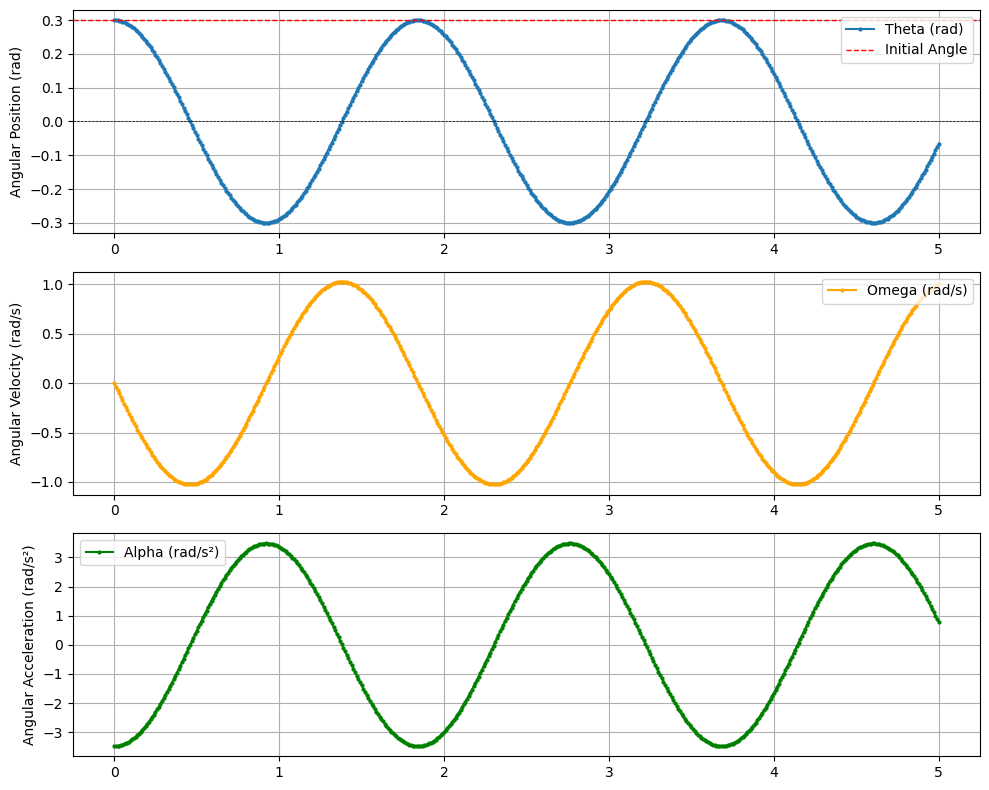

In [43]:
history = pendulum.get_history()

times = history["q"]['time']
thetas = history["q"]['values']
omegas = history["omega"]['values']
alphas = history["alpha"]['values']

style = {'marker': 'o', 'markersize': 2, 'linestyle': '-'}
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(times, thetas, label='Theta (rad)', **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"].start, color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.grid()
plt.legend(loc='upper right')
plt.ylabel('Angular Position (rad)')

plt.subplot(3, 1, 2)
plt.plot(times, omegas, label='Omega (rad/s)', color='orange', **style)
plt.grid()
plt.legend(loc='upper right')
plt.ylabel('Angular Velocity (rad/s)')

plt.subplot(3, 1, 3)
plt.plot(times, alphas, label='Alpha (rad/s²)', color='green', **style)
plt.grid()
plt.legend(loc='upper right')
plt.ylabel('Angular Acceleration (rad/s²)')

plt.legend()
plt.tight_layout()
plt.show()

## Step 8: Comparing Configurations

In [ ]:
default_config = pendulum.get_parameters()
L_default = float(str(default_config['L'].start))
m_default = float(str(default_config['m'].start))

print(f"L_default: {L_default}, m_default: {m_default}")

In [ ]:
config1 = {
    'L': 2 * L_default,
    'm': 2 * m_default,
}

config2 = {
    'L': 0.5 * L_default,
    'm': 0.5 * m_default
}

labels = ['Default', 'Config 1 - Increased $L, m$', 'Config 2 - Reduced $L, m$']
configs = [default_config, config1, config2]
histories = []


for i, config in enumerate(configs):
    pendulum.reset()
    pendulum.set_parameters(**config)
    
    pendulum.initialize(t0=0.0)
    for t in time_points:
        pendulum.do_step(t, dt)
    
    histories.append(pendulum.get_history())

plt.figure(figsize=(10, 6))
for i, history in enumerate(histories):
    times = history["theta"]['time']
    thetas = history["theta"]['values']
    plt.plot(times, thetas, label=labels[i], **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.title('Pendulum Angular Position for Different Configurations')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (rad)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.grid()